In [6]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import captum
from captum.attr._utils.input_layer_wrapper import ModelInputWrapper
from captum.attr import (
    IntegratedGradients,
    GuidedBackprop,
    GuidedGradCam,
    LayerGradCam,
    NoiseTunnel,
    GradientShap,)
from models.utils import get_classification_model
import misc
import numpy as np
import torch

from utils.config_object import make_config_object
import config as config_file
from data_preproc.data_preproc_functions import  Logger

logger = Logger(output_filename=None, suppress_CLI_prints=False)
config = make_config_object(config_file)

device =  torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
config.device = device

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import utils.load_data as load_data
from data_preproc.data_preproc_functions import copy_file, copy_folder, create_folder_if_not_exists, Logger


torch.backends.cudnn.enabled = False


train_dict, val_dict, test_dict = load_data.get_files(config=config, logger=logger)

(train_dl, val_dl, test_dl, batch_size, channels, depth, height, width, 
            n_features, train_dict, val_dict, test_dict) = \
            load_data.main(config=config, train_dict=train_dict, val_dict=val_dict, test_dict=test_dict,
                           fold=0, drop_last=config.dataloader_drop_last, logger=logger, save_patient_ids_file=False)

2024-07-24 17:37:17 - INFO: Creating c:\Users\d.c.macrae\Documents\DL_NTCP_Multitox\datasets\MT_dataset\stratified_sampling_full_542.csv.
2024-07-24 17:37:17 - INFO: Making validation set. Size = 0.2 (157 patients)
2024-07-24 17:37:17 - INFO: Stratifed sampling based on columns: ['CT+C', 'CT_Artefact', 'Photons', 'Loctum2']
2024-07-24 17:37:17 - INFO: Stratified sampling returned too small of a test set (155). Randomly sampling 2 samples from the training set.
2024-07-24 17:37:17 - INFO: >>> FULL <<<
2024-07-24 17:37:17 - INFO: Expected size (fraction): 984 (100%)
2024-07-24 17:37:17 - INFO: Size (fraction): 984 (100.0%)
2024-07-24 17:37:17 - INFO: Group: CT+C
2024-07-24 17:37:17 - INFO: 	Value = 0, 	Proportion = 18.801% (185)
2024-07-24 17:37:17 - INFO: 	Value = 1, 	Proportion = 81.199% (799)
2024-07-24 17:37:17 - INFO: 
2024-07-24 17:37:17 - INFO: Group: CT_Artefact
2024-07-24 17:37:17 - INFO: 	Value = 0.0, 	Proportion = 79.268% (780)
2024-07-24 17:37:17 - INFO: 	Value = 1.0, 	Propor

In [16]:
#config_file.model_name = 'ViT'
config.transfer_learning_mode = False
pretrained_path = "C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/experiments/TransRP_ResNet18_m2 FIX/20240630_062831_1_101_37_TransRP_ResNet18_m2_params_121360641_auc_tr_0.746_val_0.731_test_0.723/best_model.pth"
#pretrained_path = "C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/experiments/TransRP_DenseNet121_m2 no shared layer/20240623_195037_1_101_49_TransRP_DenseNet121_m2_params_99804801_auc_tr_0.802_val_0.732_test_0.726/best_model.pth"
#pretrained_path = "C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/final_models_2/Best_ResNet_2/20240626_164205_5_101_4_resnet_lrelu_params_88229_auc_tr_0.7_val_0.732_test_0.724_avg_tr_0.733_val_0.723_test_0.725_ens_0.727/best_model.pth"
# model, n_params = get_classification_model(config, channels=3, depth=96, height=96, width=96, n_features=len(config.features_dl), pretrained_path=pretrained_path, logger=logger, save_summary=False)

#pretrained_path = "C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/final_models_2/Best_ConvNeXt_2/20240626_190455_4_101_27_convnext_small_params_52192773_auc_tr_0.735_val_0.718_test_0.717/best_model.pth"

pretrained_path = "Z:/Daniel/TransRP Experiments 2/TransRP_ResNet18_m2 features/20240701_051551_4_101_47_TransRP_ResNet18_m2_params_122913577_auc_tr_0.757_val_0.724_test_0.73/best_model.pth"
#pretrained_path = "C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/experiments/TransRP_ResNet18_m2/20240622_180411_5_101_37_TransRP_ResNet18_m2_params_121328961_auc_tr_0.751_val_0.727_test_0.722_avg_tr_0.753_val_0.721_test_0.716_ens_0.732/best_model.pth"
#pretrained_path = "C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/final_models_2/Best ViT/20240626_092504_1_101_7_ViT_params_1623909_auc_tr_0.719_val_0.727_test_0.723/best_model.pth"

#pretrained_path = "C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/final_models_2/Best_DCNN_Pooling_2/20240626_163549_1_101_8_dcnn_pooling_params_235109_auc_tr_0.697_val_0.713_test_0.724/best_model.pth"

pretrained_path = r"experiments\HXM\20240724_162245_2_101_24_dcnn_pooling_params_59118_auc_tr_0.769_val_0.713_test_0.765\best_model.pth"
model, n_params = get_classification_model(config, channels=3, depth=96, height=96, width=96, n_features=len(config.features_dl), pretrained_path=pretrained_path, logger=logger, save_summary=False)



# 
# print()



2024-07-24 17:39:45 - INFO: Weight init name: kaiming_uniform.
2024-07-24 17:39:45 - INFO: Using pretrained weights: experiments\HXM\20240724_162245_2_101_24_dcnn_pooling_params_59118_auc_tr_0.769_val_0.713_test_0.765\best_model.pth.


Layer (type (var_name))                                 Input Shape               Output Shape              Param #                   Kernel Shape
MultiTox_Classifier (MultiTox_Classifier)               [8, 3, 96, 96, 96]        [8, 1]                    --                        --
├─DCNN_Pooling (encoder)                                [8, 3, 96, 96, 96]        [8, 32, 3, 3, 3]          --                        --
│    └─ModuleList (first_conv_blocks)                   --                        --                        --                        --
│    │    └─small_conv_block (conv_block1_0)            [8, 1, 96, 96, 96]        [8, 8, 48, 48, 48]        --                        --
│    │    │    └─conv3d_padding_same (pad)              [8, 1, 96, 96, 96]        [8, 1, 102, 102, 102]     --                        [7, 7, 7]
│    │    │    └─Conv3d (conv1)                         [8, 1, 102, 102, 102]     [8, 8, 48, 48, 48]        2,752                     [7, 7, 7]
│    │    │    └─

In [17]:
model = ModelInputWrapper(model)

model.to(device)

attr = IntegratedGradients(model)
#attr = GradientShap(model)

#attr = GuidedBackprop(model)
# attr = GuidedGradCam(model, model.encoder.features.denseblock_4.denselayer1.layers.conv1)
#attr = GuidedGradCam(model, model.output_head.transformer.norm)

In [18]:
dataloader = test_dl


all_preds = []
model.eval()


image_attributions_dict = {}
features_attributions_dict = {}
total_attention_per_endpoint = {endpoint : torch.zeros(3,96,96,96) for endpoint in config.endpoint_list}
total_feature_attention_per_endpoint = {endpoint : torch.zeros(1,len(config.features_dl)) for endpoint in config.endpoint_list}


from tqdm import tqdm

i = 1
for data in tqdm(dataloader):
    # Load data
    inputs, features, label_list = (
        data['ct_dose_seg'].to(device),
        data['features'].to(device),
        data['label_list'].to(device),
        )
    

    
    #print(inputs.shape)

    model_input = (inputs, features)
    baseline_input = (torch.zeros_like(inputs), torch.randn_like(features))

    for idx, endpoint in enumerate(config.endpoint_list):
    
        #(image_attention, features_attention) = attr.attribute(model_input, additional_forward_args=(True), target=idx, n_steps=10)
        (image_attention, features_attention) = attr.attribute(model_input, baseline_input, additional_forward_args=(True), target=idx)

        

        image_attributions_dict[endpoint] = image_attention.cpu().numpy()
        features_attributions_dict[endpoint] = features_attention.cpu().numpy()

        total_attention_per_endpoint[endpoint] += image_attributions_dict[endpoint]
        total_feature_attention_per_endpoint[endpoint] += features_attributions_dict[endpoint]

    i += 1
    if i >= 1:
        break





for endpoint in config.endpoint_list:
    total_attention_per_endpoint[endpoint] /= len(dataloader)
    total_feature_attention_per_endpoint[endpoint] /= len(dataloader)

  0%|          | 0/197 [00:32<?, ?it/s]


In [19]:
image_attributions_dict[endpoint].shape

(1, 3, 96, 96, 96)

In [28]:
image_attributions_dict[endpoint][0][2].max()

0.013464553197318993

C:\Users\d.c.macrae\AppData\Local\Temp\2\ipykernel_11788\569565413.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


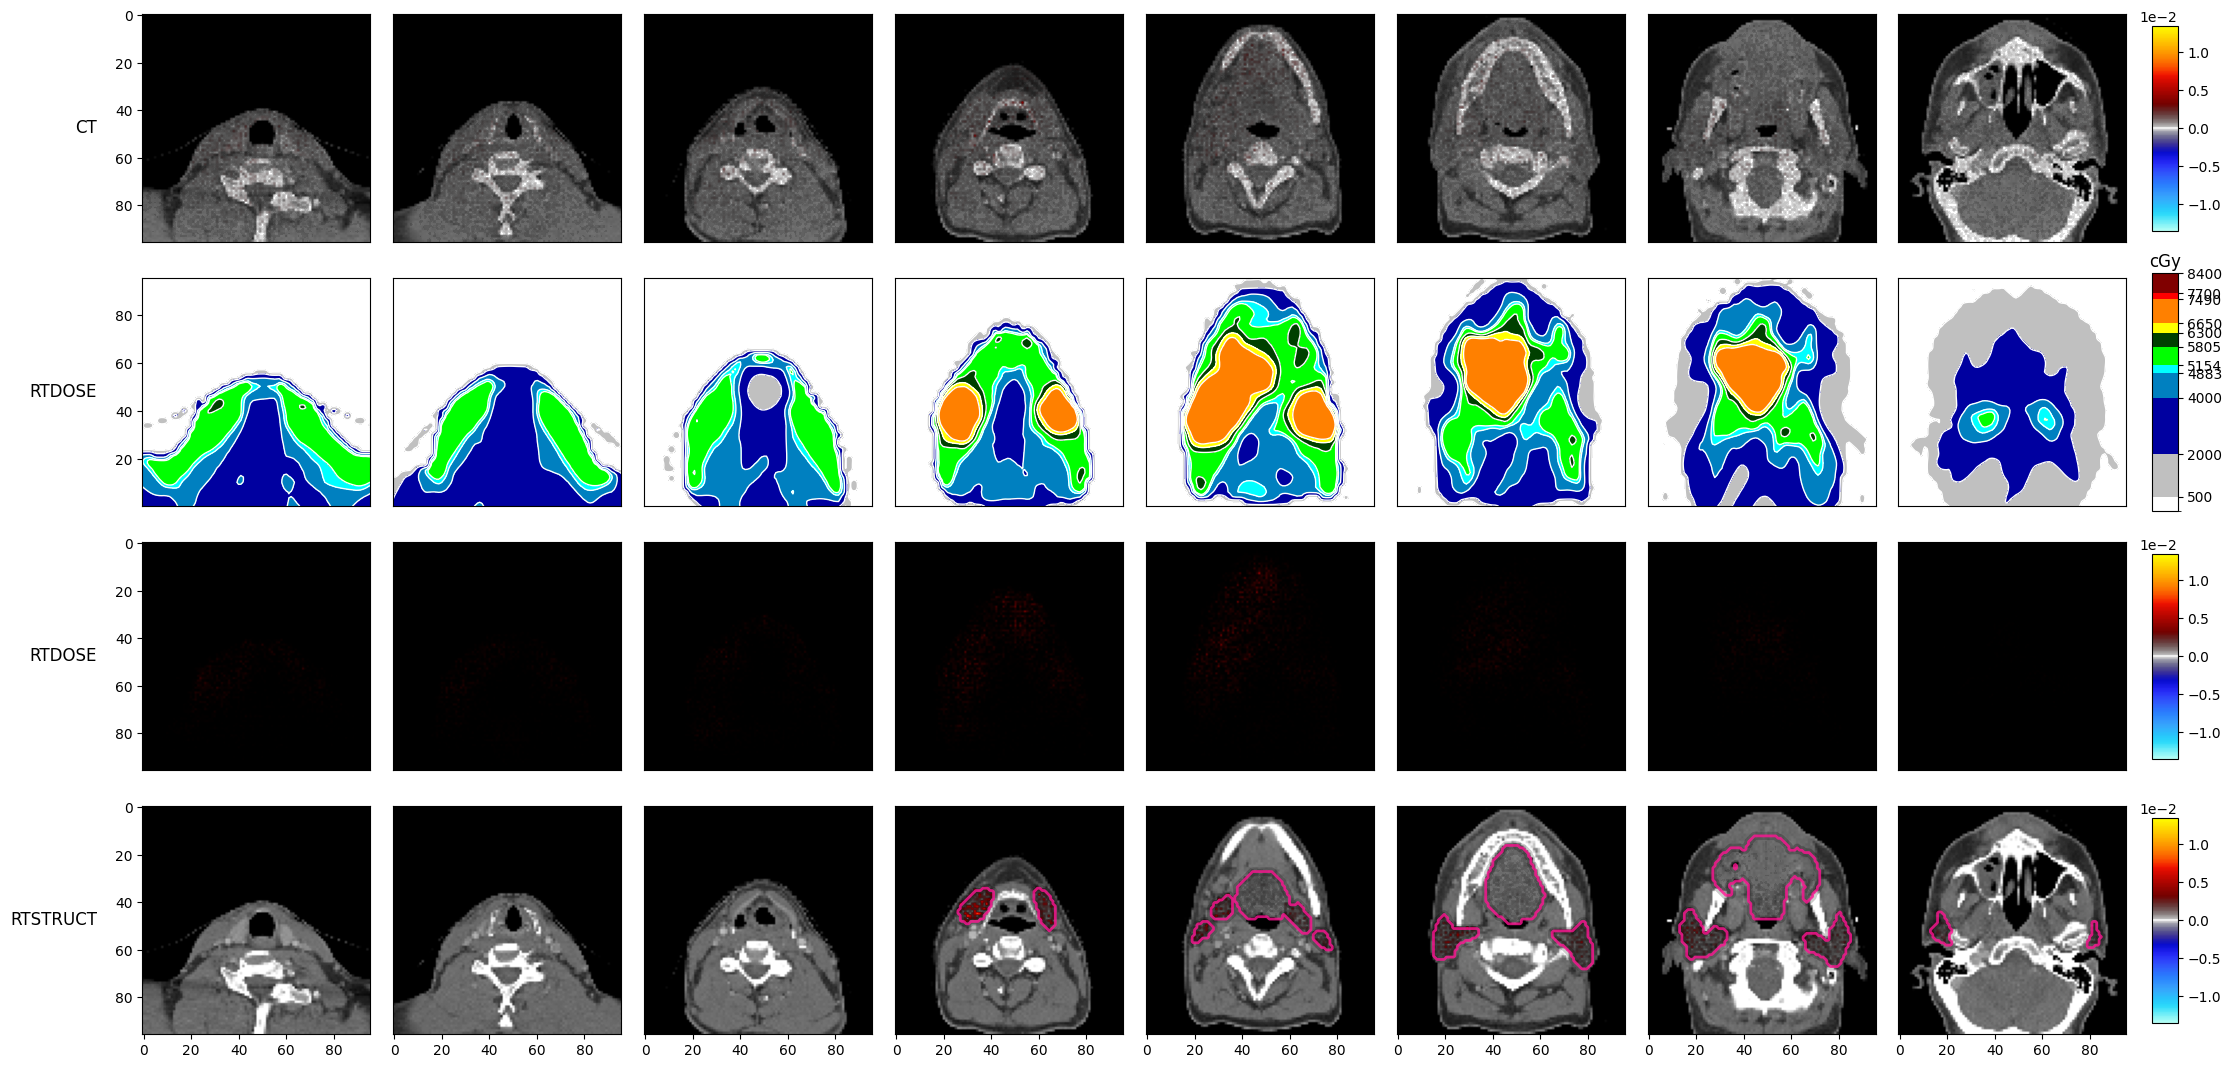

In [29]:
%matplotlib inline
from data_preproc.checks.plotting_functions import plot_slices


CT = model_input[0][0][0].cpu()
RTDOSE = model_input[0][0][1].cpu()
RTSTRUCT = model_input[0][0][2].cpu()

endpoint = "Xerostomia_M06"
endpoint_attention = image_attributions_dict[endpoint][0]

plotting_rows_dicts = [
            {
                "Label": "CT",
                "CT": CT,
                "Attention" : endpoint_attention[0]
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE,
                #"Attention" : smoothed_image_attention[1]
            },
            {
                "Label": "RTDOSE",
                #"RTDOSE": RTDOSE,
                "Attention" : endpoint_attention[1]
            },
            {
                "Label": "RTSTRUCT",
                "CT"    : CT,
                "RTSTRUCT": RTSTRUCT,
                "Attention" : endpoint_attention[2]
            }
        ]

slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , title=f"{patient_id} slices")

fig.show()

In [ ]:
%matplotlib inline
from data_preproc.checks.plotting_functions import plot_slices


summed_image_attentions = {endpoint : np.sum(image_attributions_dict[endpoint][0], axis=0) for endpoint in config.endpoint_list}

#mean_image_attention = [np.mean(np.array(list(total_attention_per_endpoint[:][i].values())), axis=0) for i in range(3)]


plotting_rows_dicts = [ {"Label" : endpoint, "Attention" : image_attributions_dict[endpoint][0][1]} for endpoint in config.endpoint_list]


#plotting_rows_dicts = [ {"Label" : endpoint, "Attention" : total_attention_per_endpoint[endpoint][0][0].cpu().numpy()} for endpoint in config.endpoint_list]


slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , ti tle=f"{patient_id} slices")

In [ ]:
mean_image_attention.shape

In [ ]:
image_attention.max()

In [ ]:
features_attention.max()

In [ ]:
mean_image_attention.shape

In [ ]:
image_attributions_dict["Aspiration_M06"].shape

In [ ]:
summed_image_attentions["Aspiration_M06"].shape

In [ ]:

#image_attention = attributions[0].cpu().detach().numpy()[0]
#features_attention = attributions[1].cpu().detach().numpy()
image_attention = attributions[0][0]
model_inputs = inputs[0]
model_features = attributions[1]

#del attributions

torch.cuda.empty_cache()

In [ ]:
%matplotlib inline
from data_preproc.checks.plotting_functions import plot_slices


CT = model_inputs[0].cpu()
RTDOSE = model_inputs[1].cpu()
RTSTRUCT = model_inputs[2].cpu()

plotting_rows_dicts = [
            {
                "Label": "CT",
                "CT": CT,
                "Attention" : smoothed_image_attention[0]
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE,
                #"Attention" : smoothed_image_attention[1]
            },
            {
                "Label": "RTDOSE",
                #"RTDOSE": RTDOSE,
                "Attention" : smoothed_image_attention[1]
            },
            {
                "Label": "RTSTRUCT",
                "CT"    : CT,
                "RTSTRUCT": RTSTRUCT,
                "Attention" : smoothed_image_attention[2]
            }
        ]

slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , ti tle=f"{patient_id} slices")

fig.show()


In [ ]:
image_attention = attributions[0].cpu().detach().numpy()

In [ ]:
image_attention.shape

In [ ]:
from data_preproc.checks.plotting_functions import plot_slices


CT = inputs[0][0].detach().cpu().numpy()
RTDOSE = inputs[0][1].detach().cpu().numpy()
RTSTRUCT = inputs[0][2].detach().cpu().numpy()

from scipy.ndimage import gaussian_filter
smoothed_saliency = saliency.detach().cpu().numpy().copy()
for i in range(saliency.shape[0]):
    smoothed_saliency[i] = gaussian_filter(saliency[i, :, :, :].detach().cpu().numpy(), 2)


plotting_rows_dicts = [
            {
                "Label": "CT + attention",
                "CT": CT,
                "Attention" : smoothed_saliency[0]
            },
            #  {
            #     "Label": "CT + attention",
            #     #"CT": CT,
            #     "Attention" : saliency[0].detach().cpu().numpy()
            # },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE,
                #"Attention" : image_attention[1]
            },
            {
                "Label": "RTDOSE attention",
                #"RTDOSE": RTDOSE,
                "Attention" : smoothed_saliency[1]
            },
            {
                "Label": "RTSTRUCT + attention",
                "CT"    : CT,
                "RTSTRUCT": RTSTRUCT,
                "Attention" : smoothed_saliency[2]
            }
        ]

slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , title=f"{patient_id} slices")

fig.show()

In [ ]:
inputs.shape

In [ ]:
%matplotlib inline



In [ ]:
image_attention.shape

In [ ]:
from scipy.ndimage import gaussian_filter
smoothed_image_attention = image_attention.cpu().detach().numpy().copy()
for i in range(image_attention.shape[0]):
    smoothed_image_attention[i] = gaussian_filter(image_attention[i, :, :, :].cpu().numpy(), 1)
#smoothed_image_attention = gaussian_filter(image_attention[:, :, :], 2)

In [ ]:
%matplotlib inline
from data_preproc.checks.plotting_functions import plot_slices


CT = model_inputs[0].cpu()
RTDOSE = model_inputs[1].cpu()
RTSTRUCT = model_inputs[2].cpu()

attention_summed = np.sum(smoothed_image_attention, axis=0)

plotting_rows_dicts = [
            {
                "Label": "CT",
                "CT": CT,
                #"Attention" : smoothed_image_attention[0]
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE,
                #"Attention" : smoothed_image_attention[1]
            },
            {
                "Label": "RTDOSE",
                #"RTDOSE": RTDOSE,
                "Attention" : attention_summed
            },
            {
                "Label": "RTSTRUCT",
                "CT"    : CT,
                "RTSTRUCT": RTSTRUCT,
                #"Attention" : smoothed_image_attention[2]
            }
        ]

slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , title=f"{patient_id} slices")

fig.show()


In [ ]:
%matplotlib inline
from data_preproc.checks.plotting_functions import plot_slices


CT = model_inputs[0].cpu()
RTDOSE = model_inputs[1].cpu()
RTSTRUCT = model_inputs[2].cpu()

plotting_rows_dicts = [
            {
                "Label": "CT",
                "CT": CT,
                "Attention" : smoothed_image_attention[0]
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE,
                #"Attention" : smoothed_image_attention[1]
            },
            {
                "Label": "RTDOSE",
                #"RTDOSE": RTDOSE,
                "Attention" : smoothed_image_attention[1]
            },
            {
                "Label": "RTSTRUCT",
                "CT"    : CT,
                "RTSTRUCT": RTSTRUCT,
                "Attention" : smoothed_image_attention[2]
            }
        ]

slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , title=f"{patient_id} slices")

fig.show()


In [ ]:
%matplotlib inline
from data_preproc.checks.plotting_functions import plot_slices


CT = model_inputs[0].cpu()
RTDOSE = model_inputs[1].cpu()
RTSTRUCT = model_inputs[2].cpu()

plotting_rows_dicts = [
            {
                "Label": "CT",
                "CT": CT,
                "Attention" : smoothed_image_attention[0]
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE,
                #"Attention" : smoothed_image_attention[1]
            },
            {
                "Label": "RTDOSE",
                #"RTDOSE": RTDOSE,
                "Attention" : smoothed_image_attention[1]
            },
            {
                "Label": "RTSTRUCT",
                "CT"    : CT,
                "RTSTRUCT": RTSTRUCT,
                "Attention" : smoothed_image_attention[2]
            }
        ]

slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , title=f"{patient_id} slices")

fig.show()


In [ ]:
import numpy as np

CT = model_inputs[0].cpu()
RTDOSE = model_inputs[1].cpu()
RTSTRUCT = model_inputs[2].cpu()

plotting_rows_dicts = [
            {
                "Label": "CT + attention",
                "CT": CT,
                "Attention" : image_attention[0].cpu().numpy()
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE,
                #"Attention" : image_attention[1]
            },
            {
                "Label": "RTDOSE attention",
                #"RTDOSE": RTDOSE,
                "Attention" : image_attention[1].cpu().numpy()
            },
            {
                "Label": "RTSTRUCT + attention",
                "CT"    : CT,
                "RTSTRUCT": RTSTRUCT,
                "Attention" : image_attention[2].cpu().numpy()
            }
        ]

slices = [0, 20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , title=f"{patient_id} slices")

fig.show()

In [ ]:
image_attention.min()

In [ ]:
plotting_rows_dicts = [
            {
                "Label": "CT + attention",
                "CT": CT,
                "Attention" : image_attention[0]
            },
            {
                "Label": "RTDOSE",
                "RTDOSE": RTDOSE,
                #"Attention" : image_attention[1]
            },
            {
                "Label": "RTDOSE attention",
                #"RTDOSE": RTDOSE,
                "Attention" : image_attention[1]
            },
            {
                "Label": "RTSTRUCT + attention",
                "CT"    : CT,
                "RTSTRUCT": RTSTRUCT,
                "Attention" : image_attention[2]
            }
        ]

slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices)# , title=f"{patient_id} slices")

fig.show()

# GradientSHAP for clinical features

In [8]:
dataloader = test_dl


all_preds = []
model.eval()


all_feature_values = []
all_feature_gradients_per_endpoint = {endpoint:[] for endpoint in config.endpoint_list}

from tqdm import tqdm

i = 0
for data in tqdm(dataloader):
    # Load data
    inputs, features, label_list = (
        data['ct_dose_seg'].to(device),
        data['features'].to(device),
        data['label_list'].to(device),
        )
    

    
    #print(inputs.shape)

    model_input = (inputs, features)
    baseline_input = (torch.randn_like(inputs), torch.randn_like(features))

    all_feature_values.append(features.cpu().numpy())
    
    for idx, endpoint in enumerate(config.endpoint_list):
    
        #(image_attention, features_attention) = attr.attribute(model_input, additional_forward_args=(True), target=idx, n_steps=10)
        (image_attention, features_attention) = attr.attribute(model_input, baseline_input, additional_forward_args=(True), target=idx)

        
        all_feature_gradients_per_endpoint[endpoint].append(features_attention.cpu().numpy())




100%|██████████| 218/218 [05:37<00:00,  1.55s/it]


In [9]:
all_feature_values = np.concatenate(all_feature_values, axis=0)

all_feature_gradients_per_endpoint = {endpoint : np.concatenate(all_feature_gradients_per_endpoint[endpoint], axis=0) for endpoint in config.endpoint_list}

num_features = all_feature_values.shape[1]

In [10]:
num_features

35

100%|██████████| 35/35 [4:06:40<00:00, 422.86s/it]  


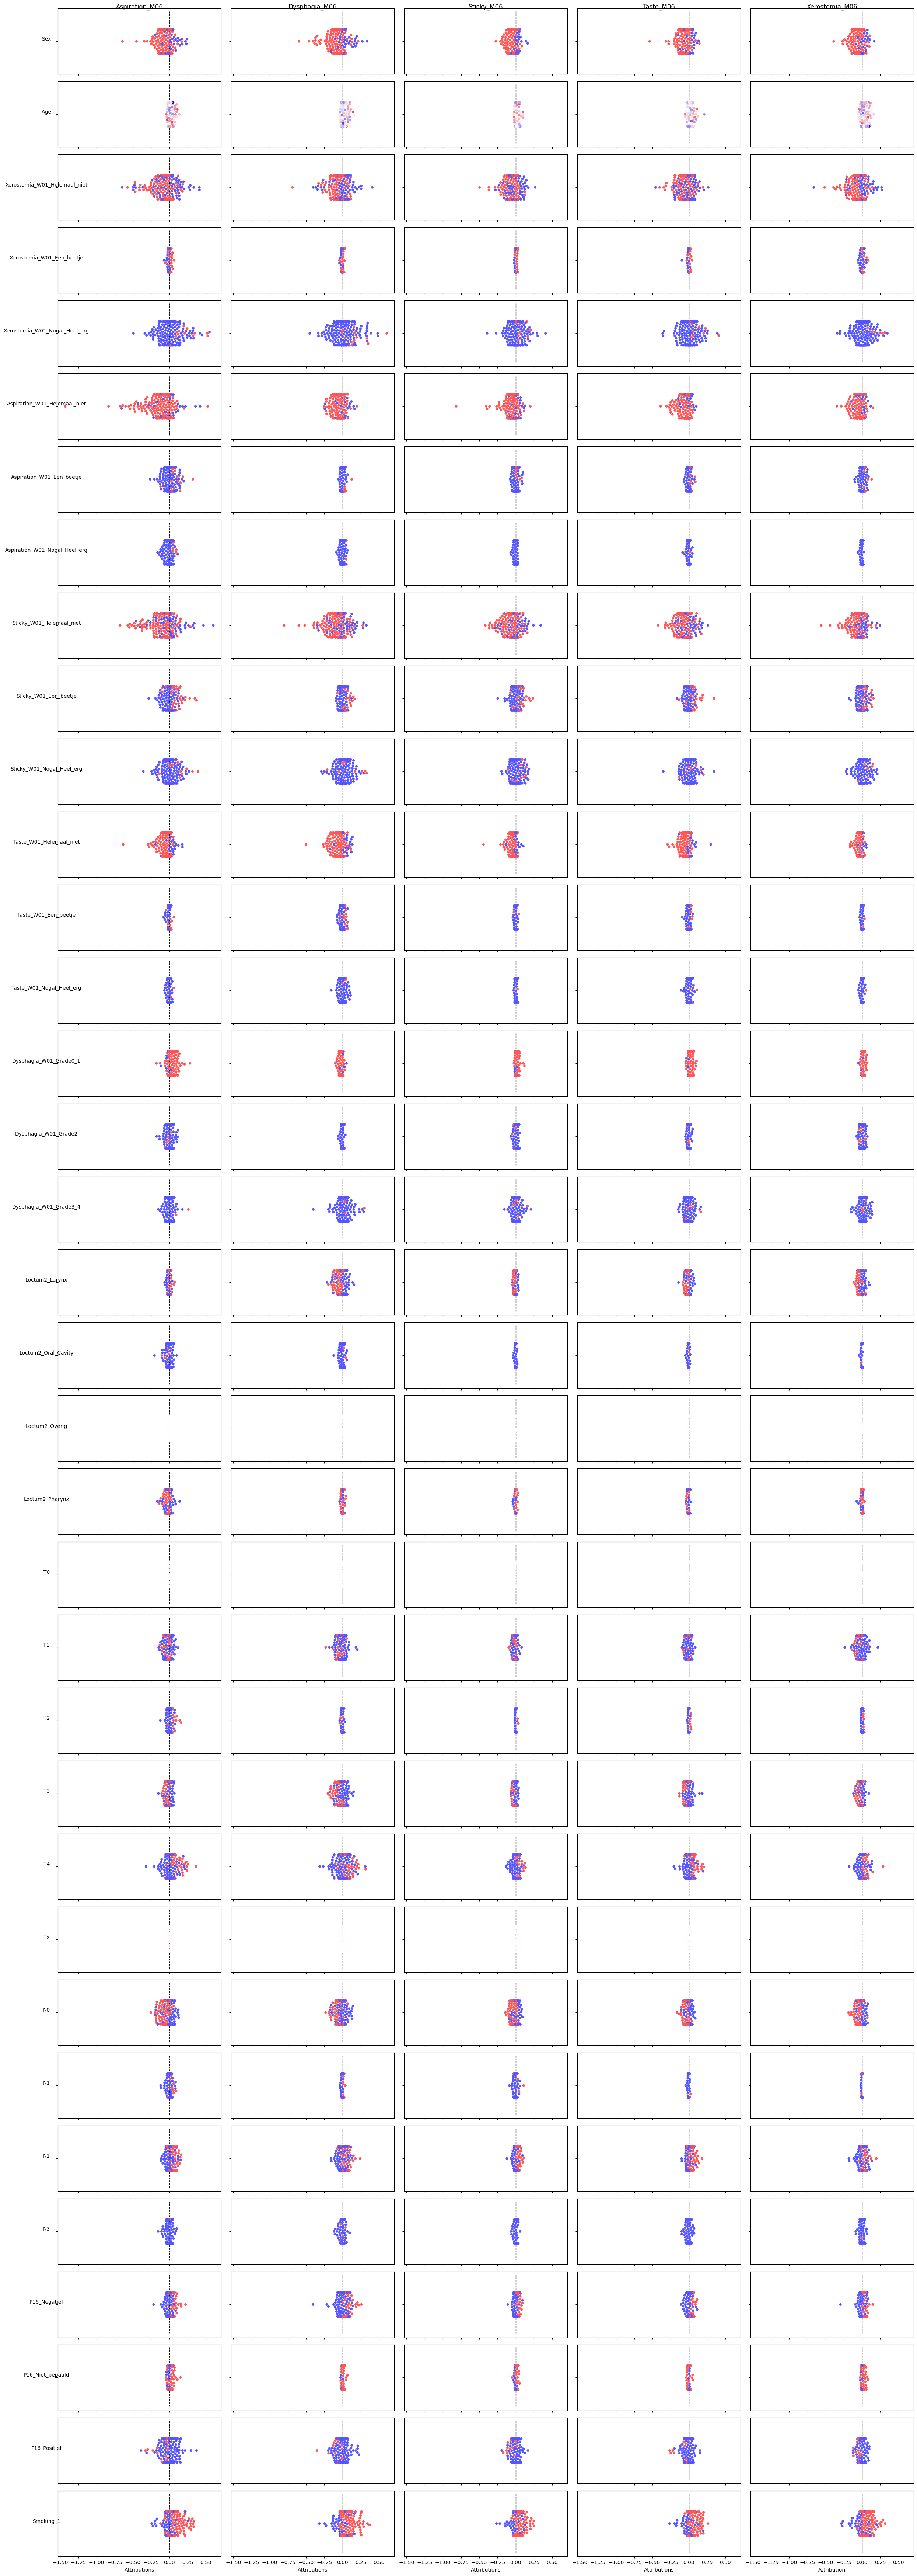

In [11]:
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

num_endpoints = len(config.endpoint_list)
fig, axs = plt.subplots(num_features, num_endpoints, figsize=(5 * num_endpoints, 2*num_features), sharex=True)
#endpoint = "Xerostomia_M06"
for i in tqdm(range(num_features)):
    feature_name = config.features_dl[i]
    feature_values = all_feature_values[:, i]

    for j, endpoint_name in enumerate(config.endpoint_list):
        #for idx, endpoint in enumerate(config.endpoint_list):
        
        attributions = all_feature_gradients_per_endpoint[endpoint_name][:, i]
        #print(all_feature_values.shape, all_feature_gradients_per_endpoint[endpoint].shape)
        #print(attributions.shape, feature_values.shape)

        data = pd.DataFrame({
            'Attributions' : attributions,
            'Feature Value' : feature_values
        })
        if feature_name.lower() != "age":
            sns.swarmplot(data=data, x='Attributions', hue='Feature Value', palette="seismic", ax=axs[i, j], size=5, legend=False)
        else:
            sns.swarmplot(data=data, x='Attributions', hue='Feature Value', palette="bwr", ax=axs[i, j], size=5, legend=False)
        axs[i, j].plot([0, 0], [-1, 1], 'k--', lw=1)
        #axs[i, j].set_title(config.features_dl[i])


pad = 15
for ax, endpoint in zip(axs[0], config.endpoint_list):
    ax.annotate(endpoint, xy=(0.5, 1), xytext=(0, 0),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')
    

for ax, feature in zip(axs[:,0], config.features_dl):
    ax.set_ylabel(feature, rotation=0, labelpad=15)

plt.xlabel('Attribution')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:

plt.close()